age: [39 50 38 53 28 37 49 52 31 42 30 23 32 40 34 25 43 54 35 59 56 19 20 45
 22 48 21 24 57 44 41 29 18 47 46 36 79 27 67 33 76 17 55 61 70 64 71 68
 66 51 58 26 60 90 75 65 77 62 63 80 72 74 69 73 81 78 88 82 83 84 85 86
 87]
workclass: ['State gov' 'Self emp not inc' 'Private' 'Federal gov' 'Local gov' None
 'Self emp inc' 'Without pay' 'Never worked']
education: ['Bachelors' 'HS grad' '11th' 'Masters' '9th' 'Some college' 'Assoc acdm'
 'Assoc voc' '7th 8th' 'Doctorate' 'Prof school' '5th 6th' '10th'
 '1st 4th' 'Preschool' '12th']
education_num: [13  9  7 14  5 10 12 11  4 16 15  3  6  2  1  8]
marital_status: ['Never married' 'Married civ spouse' 'Divorced' 'Married spouse absent'
 'Separated' 'Married AF spouse' 'Widowed']
occupation: ['Adm clerical' 'Exec managerial' 'Handlers cleaners' 'Prof specialty'
 'Other service' 'Sales' 'Craft repair' 'Transport moving'
 'Farming fishing' 'Machine op inspct' 'Tech support' None
 'Protective serv' 'Armed Forces' 'Priv house serv']
relatio

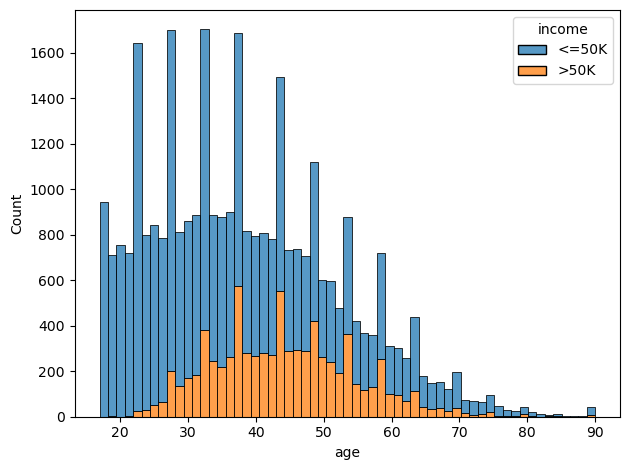

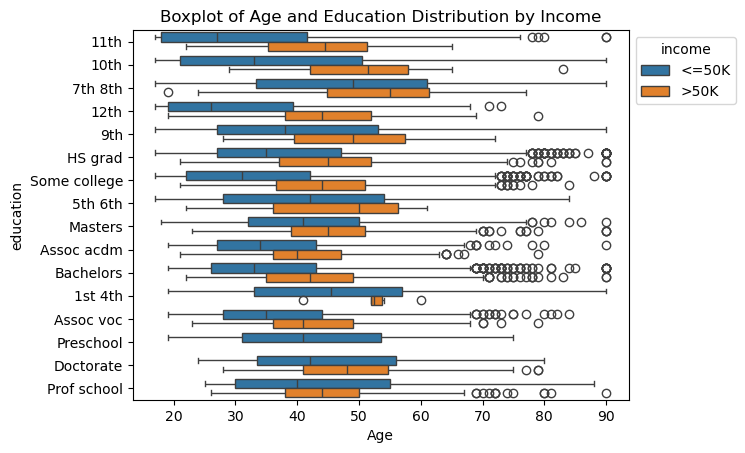

       age    workclass     education  education-num         marital-status  \
1901    65  Without pay       7th 8th              4                Widowed   
9257    19  Without pay       HS grad              9          Never married   
15533   21  Without pay       HS grad              9          Never married   
15695   22  Without pay       HS grad              9          Never married   
16812   46  Without pay       HS grad              9     Married civ spouse   
20073   65  Without pay       HS grad              9     Married civ spouse   
21944   52  Without pay       HS grad              9     Married civ spouse   
22215   19  Without pay       HS grad              9          Never married   
24596   62  Without pay    Assoc acdm             12     Married civ spouse   
25500   29  Without pay  Some college             10     Married civ spouse   
27747   72  Without pay       HS grad              9     Married civ spouse   
28829   68  Without pay  Some college             10

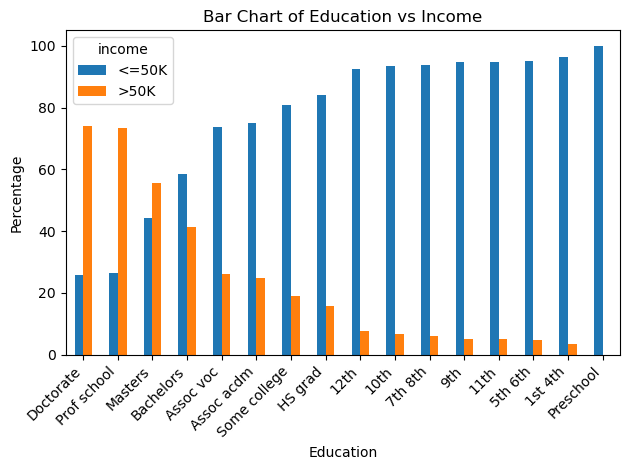

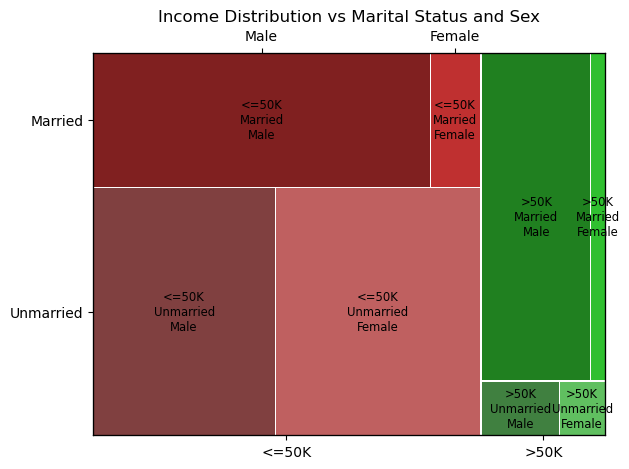

208
(32561, 17)
(30718, 17)
                  median_edu          avg_edu           
income                 <=50K  >50K      <=50K       >50K
occupation                                              
Adm clerical            10.0  10.0  10.016549  10.737673
Armed Forces             9.0  14.0   9.625000  14.000000
Craft repair             9.0   9.0   8.911041   9.792250
Exec managerial         10.0  13.0  10.838894  12.099593
Farming fishing          9.0  10.0   8.425484  10.008696
Handlers cleaners        9.0   9.0   8.453271   9.360465
Machine op inspct        9.0   9.0   8.362443   9.364000
Other service            9.0  10.0   8.717226  10.218978
Priv house serv          9.0  13.0   7.324324  13.000000
Prof specialty          13.0  14.0  12.378343  13.551372
Protective serv         10.0  10.0   9.842466  10.895735
Sales                   10.0  12.0   9.904012  11.373347
Tech support            10.0  11.0  10.871318  11.268551
Transport moving         9.0   9.0   8.653093   9.221875


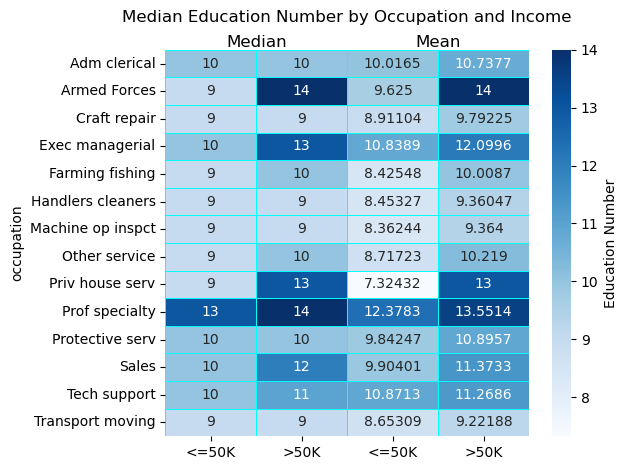

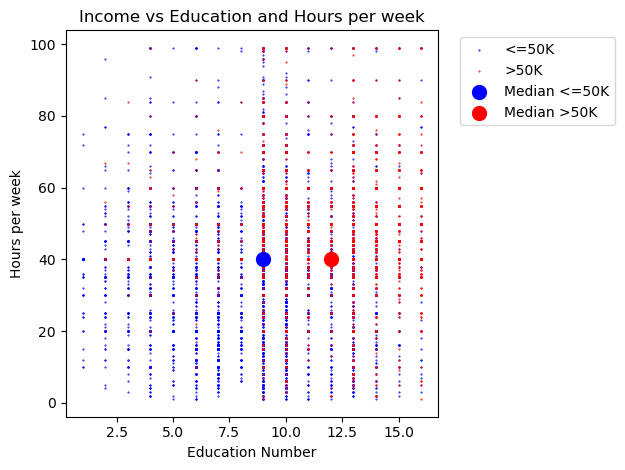

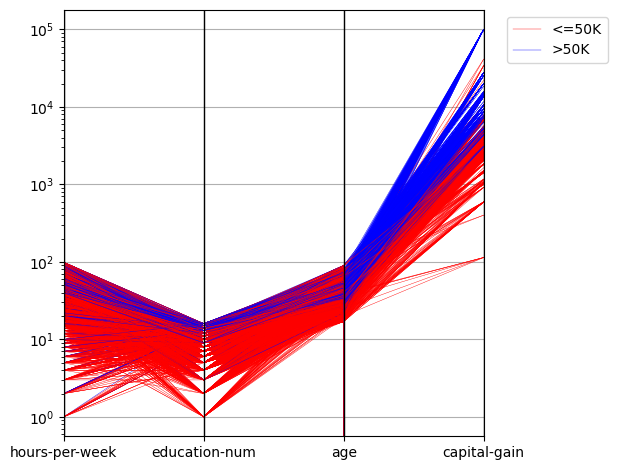

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
from pandas.plotting import parallel_coordinates, scatter_matrix
from sklearn import preprocessing
from statsmodels.graphics.mosaicplot import mosaic

attributes = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education-num",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "native-country",
    "income",
]


def clean_rows(series):
    series = series.apply(
        lambda x: " ".join(x.split("-")).strip() if isinstance(x, str) else x
    )
    series.replace("?", None, inplace=True)
    return series


def load_and_clean_data(file_path, drop_columns=None):
    data = pd.read_csv(file_path, names=attributes)
    if drop_columns:
        data.drop(columns=drop_columns, inplace=True)
    data = data.apply(lambda x: clean_rows(x))
    return data


def summarize_dataset(data):
    age = data["age"].unique()
    workclass = data["workclass"].unique()
    education = data["education"].unique()
    education_num = data["education-num"].unique()
    marital_status = data["marital-status"].unique()
    occupation = data["occupation"].unique()
    relationship = data["relationship"].unique()
    race = data["race"].unique()
    sex = data["sex"].unique()
    capital_gain = data["capital-gain"].unique()
    capital_loss = data["capital-loss"].unique()
    hours_per_week = data["hours-per-week"].unique()
    native_country = data["native-country"].unique()
    print(f"age: {age}")
    print(f"workclass: {workclass}")
    print(f"education: {education}")
    print(f"education_num: {education_num}")
    print(f"marital_status: {marital_status}")
    print(f"occupation: {occupation}")
    print(f"relationship: {relationship}")
    print(f"race: {race}")
    print(f"sex: {sex}")
    print(f"capital_gain: {capital_gain}")
    print(f"capital_loss: {capital_loss}")
    print(f"hours_per_week: {hours_per_week}")
    print(f"native_country: {native_country}")
    print(f"Number of rows: {len(data)}")
    print("Sample data:")
    # print(data.iloc[0:50])


def visualize_income_distribution(data):
    single_data = data[
        data["marital-status"].isin(
            ["Never married", "Divorced", "Separated", "Widowed"]
        )
    ]


def plot_histogram(data):
    sns.histplot(data=data, x="age", hue="income", multiple="stack")

    plt.tight_layout()
    plt.show()


def mosaic_plot(data):
    mosaic(
        data,
        ["income", "relation", "sex"],
        title="Income Distribution vs Marital Status and Sex",
    )
    plt.tight_layout()
    plt.show()


def boxplot(data):
    ax = sns.boxplot(
        data=data.sort_values(by="age"), x="age", y="education", hue="income"
    )

    plt.xlabel("Age")
    plt.ylabel("education")

    plt.title("Boxplot of Age and Education Distribution by Income")
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    plt.show()
    print(data[data["workclass"] == "Without pay"])


def bar_chart(data):
    education_income_counts = pd.crosstab(data["education"], data["income"])
    education_income_counts = education_income_counts.apply(
        lambda x: x / x.sum() * 100, axis=1
    )
    education_income_counts.sort_values(by=[">50K"], ascending=False, inplace=True)

    education_income_counts.plot(kind="bar", stacked=False)
    plt.xlabel("Education")
    plt.ylabel("Percentage")
    plt.title("Bar Chart of Education vs Income")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    # print(education_income_counts)


def heatmap(data):

    print(data[data["hours-per-week"] > 80]["hours-per-week"].count())

    print(data.shape)
    cleaned_data = data[data["workclass"].notna() & data["occupation"].notna()]

    print(cleaned_data.shape)
    grouped_data = (
        data.groupby(["occupation", "income"])
        .agg(
            median_edu=("education-num", "median"),
            avg_edu=("education-num", "mean"),
        )
        .unstack(level=1)
    )

    grouped_data = grouped_data.dropna()
    print(grouped_data)

    ax = sns.heatmap(
        grouped_data,
        annot=True,
        fmt="g",
        linewidths=0.5,
        linecolor="cyan",
        cbar_kws={"label": "Education Number"},
        cmap="Blues",
        xticklabels=["<=50K", ">50K", "<=50K", ">50K"],
    )
    ax.text(1, -0.1, "Median", ha="center", fontsize=12)
    ax.text(3, -0.1, "Mean", ha="center", fontsize=12)
    plt.xlabel("")
    plt.title("Median Education Number by Occupation and Income", pad=20)
    # plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    grouped_data2 = data.groupby(["workclass", "income"], as_index=False).agg(
        avg_hours_per_week=("hours-per-week", "mean"),
        avg_age=("age", "mean"),
        avg_capital_gain=("capital-gain", "mean"),
        avg_capital_loss=("capital-loss", "mean"),
    )


def scatter_plot(data):
    plt.scatter(
        data[data["income"] == "<=50K"]["education-num"],
        data[data["income"] == "<=50K"]["hours-per-week"],
        s=0.2,
        color="blue",
    )
    plt.scatter(
        data[data["income"] == ">50K"]["education-num"],
        data[data["income"] == ">50K"]["hours-per-week"],
        s=0.2,
        color="red",
    )
    plt.scatter(
        data[data["income"] == "<=50K"]["education-num"].median(),
        data[data["income"] == "<=50K"]["hours-per-week"].median(),
        s=100,
        color="blue",
    )
    plt.scatter(
        data[data["income"] == ">50K"]["education-num"].median(),
        data[data["income"] == ">50K"]["hours-per-week"].median(),
        s=100,
        color="red",
    )
    plt.legend(
        ["<=50K", ">50K", "Median <=50K", "Median >50K"],
        bbox_to_anchor=(1.04, 1.0),
        loc="upper left",
    )

    plt.xlabel("Education Number")
    plt.ylabel("Hours per week")
    plt.title("Income vs Education and Hours per week")
    plt.tight_layout()
    plt.show()


def parrallel_coordinates_plot(data):
    grouped_data = data[
        ["income", "hours-per-week", "education-num", "age", "capital-gain"]
    ]

    parallel_coordinates(
        grouped_data,
        "income",
        color=["red", "blue"],
        linewidth=0.3,
    )
    plt.legend(
        bbox_to_anchor=(1.04, 1.0),
        loc="upper left",
    )
    plt.tight_layout()
    plt.yscale("log")

    plt.show()


def main():
    # Load and clean the dataset
    file_path = "adult.data"
    drop_columns = ["fnlwgt"]
    data = load_and_clean_data(file_path, drop_columns)
    data["relation"] = data.apply(
        lambda x: (
            "Unmarried"
            if x["marital-status"]
            in (["Never married", "Divorced", "Separated", "Widowed"])
            else "Married"
        ),
        axis=1,
    )
    data["age-range"] = data.apply(
        lambda x: "age <25" if x["age"] < 25 else "age >=25", axis=1
    )
    data["workclass category"] = data.apply(
        lambda x: (
            "gov"
            if x["workclass"] in (["State gov", "Federal gov", "Local gov"])
            else (
                "private"
                if x["workclass"] in (["Private", "Self emp not inc", "Self emp inc"])
                else ("other")
            )
        ),
        axis=1,
    )

    summarize_dataset(data)
    print(data.head())
    plot_histogram(data)
    boxplot(data)
    bar_chart(data)
    mosaic_plot(data)
    heatmap(data)
    scatter_plot(data)
    parrallel_coordinates_plot(data)

    visualize_income_distribution(data)


if __name__ == "__main__":
    main()
